# This example uses the late exponential Chinese Hamster Ovary (CHO) model, which was developed by Meeson et al, 2025: https://doi.org/10.1002/bit.28982 

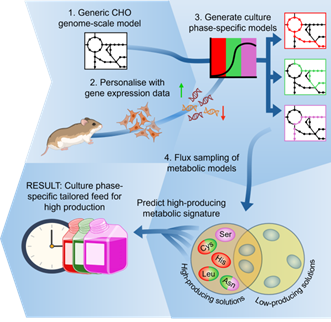

## 1. Import SIMOFF.py file from: https://github.com/katemeeson/SIMOFF
### SIMOFF.py file must be in the same folder as this Jupyter notebook for it to work

In [1]:
import SIMOFF as smf

## 2. Specify SIMOFF input
## 2a. Load COBRA model
### You can load this in from another notebook, or you can specify omics constraints/media conditions here as appropriate

In [1]:
#late exponential CHO model: https://doi.org/10.1002/bit.28982
from cobra.io import read_sbml_model
%store -r constrained_678 
model = constrained_678 

## 2b. Specify the qualitative reaction criteria
### I.e. experimental measurements, which have been transformed from continuous flux measurements to a -1, 0 or +1, corresponding to metabolite exchange or little/no activity, based on reaction reversibility. Input reactions to be considered within the objective function can be any number of model reactions. Here, we made our choice based on reactions that we know CHO cells are evolved towards with cell engineering and selection strategies

In [2]:
qualitative_criteria = {
    "ICproduct_TRANSLATION_protein": 1,   # IgG secretion (positive flux)
    "biomass_cho_prod": 1,   # Biomass production - i.e. cells are growing (positive flux)
    "EX_nh4(e)": -1,  # Ammonia uptake (negative flux)
    "EX_lac_L(e)": -1   # Lactate uptake (negative flux)
}

input_reactions = ['ICproduct_TRANSLATION_protein','biomass_cho_prod','EX_nh4(e)','EX_lac_L(e)','EX_glc(e)','EX_gln_L(e)'] #chosen since cells are evolved to optimise these phenotypes

## 3. Run SIMOFF

In [4]:
result = smf.simoff(model, input_reactions, qualitative_criteria, bounds=None, max_iter=300, initialtemp=50, maxfun=2000)
#the hyperparameters max_iter, initialtemp and maxfun are detailed on https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.dual_annealing.html and are specific to the conditions you are modelling

There are 57 possible combinations of objectives.

Updated bounds for EX_nh4(e) to allow uptake
Updated bounds for EX_lac_L(e) to allow uptake

🔸 Running single-reaction objective tests...

   Single-objective ICproduct_TRANSLATION_protein (maximisation) → Accuracy: 25.00%
   Single-objective biomass_cho_prod (maximisation) → Accuracy: 50.00%
   Single-objective EX_nh4(e) (minimisation) → Accuracy: 25.00%
   Single-objective EX_lac_L(e) (minimisation) → Accuracy: 50.00%
   Skipping EX_glc(e): not present in qualitative constraints.
   Skipping EX_gln_L(e): not present in qualitative constraints.

✅ Single-objective tests complete.


🧊 Optimisation: fitting objective(s) ['ICproduct_TRANSLATION_protein', 'biomass_cho_prod', 'EX_nh4(e)', 'EX_lac_L(e)', 'EX_glc(e)', 'EX_gln_L(e)'] to match 4 qualitative constraints
🔸 Running SIMOFF across different reaction combinations...

🔹 Testing combination['ICproduct_TRANSLATION_protein', 'biomass_cho_prod']...

SIMOFF suggested coefficients:{'ICprod

In [20]:
#store result so that you can reload when session is terminated
cho_tutorial_result = result
%store cho_tutorial_result

Stored 'cho_tutorial_result' (dict)


In [3]:
%store -r cho_tutorial_result

## 4. Visualise output
### This uses some additional python files that I have deposited onto the SIMOFF repository to let the User see what is happening on the way to the global optimum

### 4a. Visualising the trajectory of the reaction vector coefficients over the SIMOFF run

In [4]:
import Plot_coefficients as pltcf

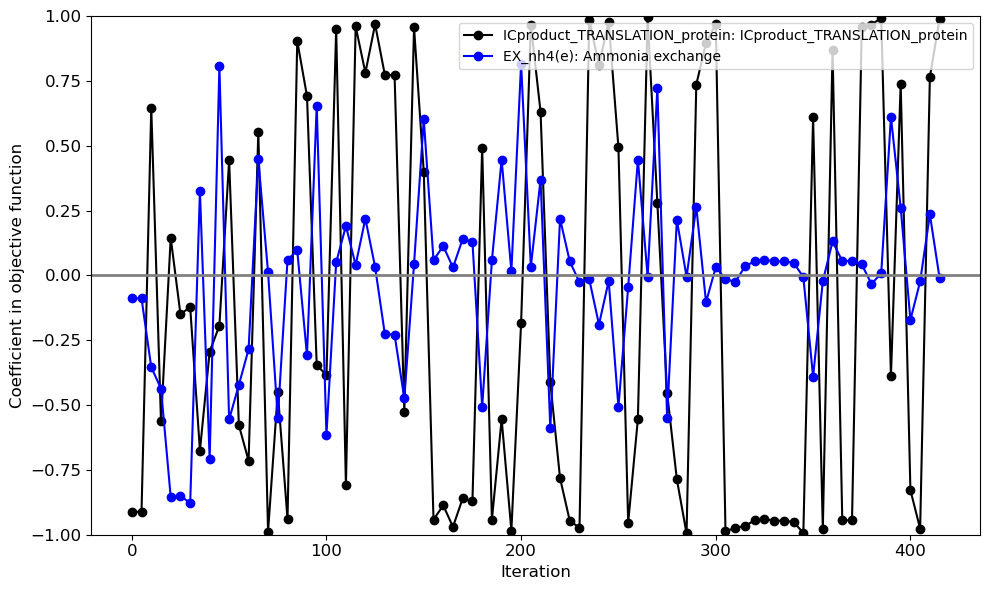

In [5]:
result = cho_tutorial_result
function_result = result['ICproduct_TRANSLATION_protein', 'EX_nh4(e)'] #this was the successful result from SIMOFF run, that I would like to plot
plot = pltcf.plot_coefficients(function_result, constrained_678, step=5)

### 4b. Visualising the mismatch of FBA to experimental, qualitative criteria over the SIMOFF run

In [6]:
import Mismatch_grid as mmg

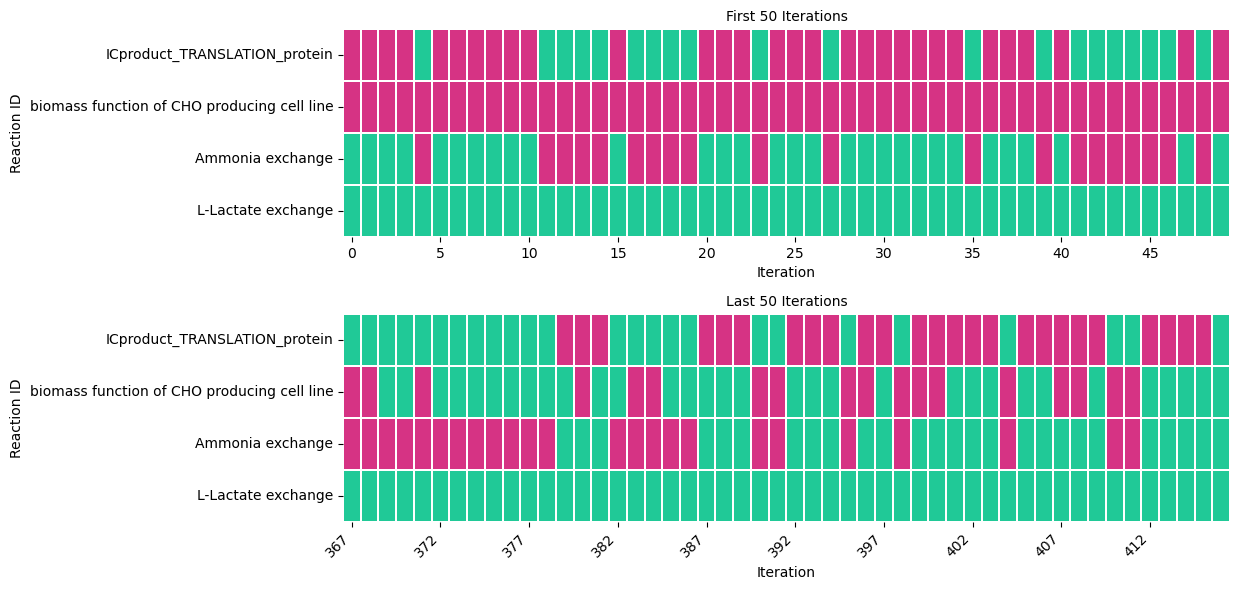

In [8]:
grid = mmg.mismatch(function_result, model, num_columns=50)

### 4c. Visualise upset-style plot to observe accuracy achieved for each combination of objective reactions

In [6]:
import Upset_plot as upst

C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the in

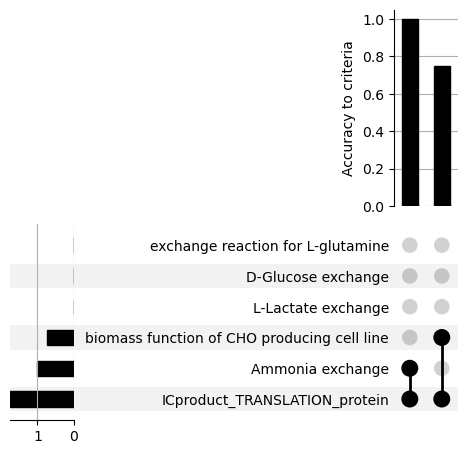

In [7]:
upset = upst.upset(result, model, input_reactions)